In [1]:
import torch
import torchmetrics
import torch.nn as nn
import torchvision

In [2]:
import numpy as np
import matplotlib.pyplot as plt

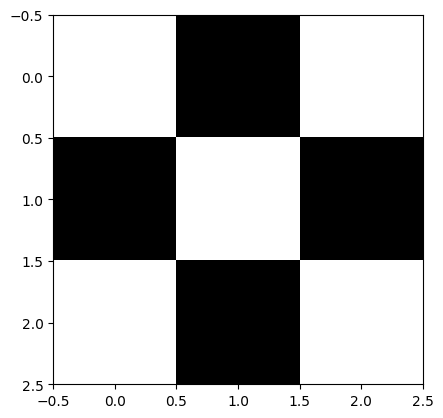

In [29]:
img_arr = np.array([
    [255, 0, 255],
    [0, 255, 0],
    [255, 0, 255]
])

plt.imshow(img_arr, cmap='grey');

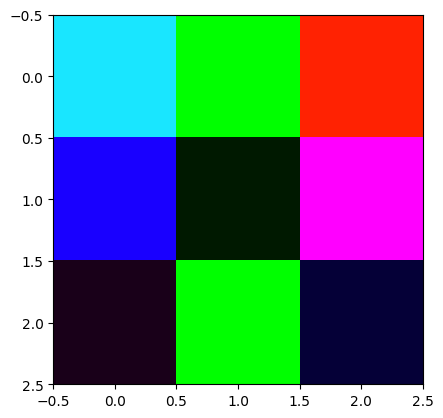

In [ ]:
img_arr = np.array([
    [
    [25, 230, 255],
    [0, 255, 0],
    [255, 34, 2]
    ],
    [
    [25, 0, 255],
    [0, 25, 0],
    [255, 0, 255]
    ],
    [
    [25, 0, 25],
    [0, 255, 0],
    [5, 0, 55]
    ]
])

plt.imshow(img_arr);

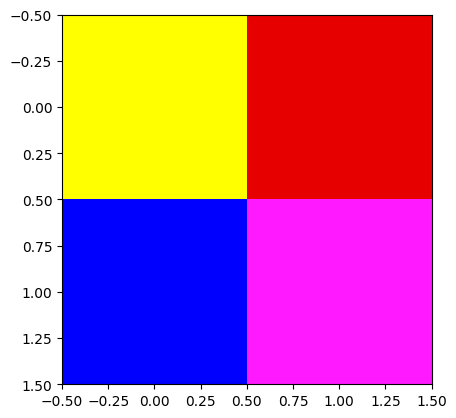

In [ ]:
img_arr = np.array([
    [
    [255, 230],
    [0, 255],
    ],
    [
    [255, 0],
    [0, 25]
    ],
    [
    [0, 0],
    [255, 255],
    ]
])

plt.imshow(img_arr.transpose(1, 2, 0));

In [ ]:
img_arr.shape

(3, 2, 2)

In [58]:
from sklearn.datasets import load_sample_images

In [70]:
sample_img = load_sample_images()['images']

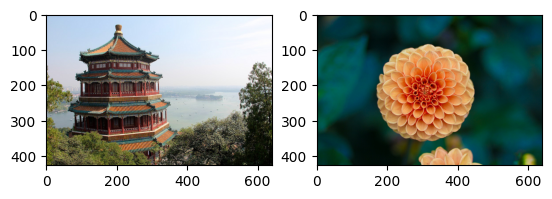

In [67]:
fig, axs = plt.subplots(1, 2)

axs[0].imshow(sample_img[0])
axs[1].imshow(sample_img[1]);

In [71]:
sample_img[1].shape

(427, 640, 3)

In [75]:
img_stack = np.stack(sample_img)

In [76]:
img_stack

array([[[[174, 201, 231],
         [174, 201, 231],
         [174, 201, 231],
         ...,
         [250, 251, 255],
         [250, 251, 255],
         [250, 251, 255]],

        [[172, 199, 229],
         [173, 200, 230],
         [173, 200, 230],
         ...,
         [251, 252, 255],
         [251, 252, 255],
         [251, 252, 255]],

        [[174, 201, 231],
         [174, 201, 231],
         [174, 201, 231],
         ...,
         [252, 253, 255],
         [252, 253, 255],
         [252, 253, 255]],

        ...,

        [[ 88,  80,   7],
         [147, 138,  69],
         [122, 116,  38],
         ...,
         [ 39,  42,  33],
         [  8,  14,   2],
         [  6,  12,   0]],

        [[122, 112,  41],
         [129, 120,  53],
         [118, 112,  36],
         ...,
         [  9,  12,   3],
         [  9,  15,   3],
         [ 16,  24,   9]],

        [[116, 103,  35],
         [104,  93,  31],
         [108, 102,  28],
         ...,
         [ 43,  49,  39],
        

In [78]:
img_stack[0, ...].shape

(427, 640, 3)

In [79]:
img_stack[1, ...].shape

(427, 640, 3)

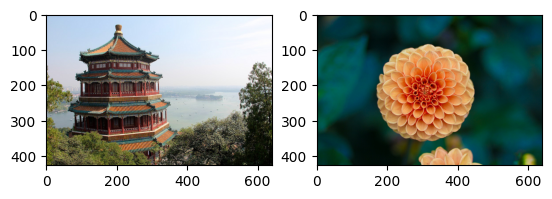

In [82]:
fig, axs = plt.subplots(1, 2)
axs[0].imshow(img_stack[0, ...])
axs[1].imshow(img_stack[1, ...]);

In [ ]:
img_stack.transpose(0, 3, 1, 2)  ### permute for torch

array([[[[174, 174, 174, ..., 250, 250, 250],
         [172, 173, 173, ..., 251, 251, 251],
         [174, 174, 174, ..., 252, 252, 252],
         ...,
         [ 88, 147, 122, ...,  39,   8,   6],
         [122, 129, 118, ...,   9,   9,  16],
         [116, 104, 108, ...,  43,  13,  15]],

        [[201, 201, 201, ..., 251, 251, 251],
         [199, 200, 200, ..., 252, 252, 252],
         [201, 201, 201, ..., 253, 253, 253],
         ...,
         [ 80, 138, 116, ...,  42,  14,  12],
         [112, 120, 112, ...,  12,  15,  24],
         [103,  93, 102, ...,  49,  21,  24]],

        [[231, 231, 231, ..., 255, 255, 255],
         [229, 230, 230, ..., 255, 255, 255],
         [231, 231, 231, ..., 255, 255, 255],
         ...,
         [  7,  69,  38, ...,  33,   2,   0],
         [ 41,  53,  36, ...,   3,   3,   9],
         [ 35,  31,  28, ...,  39,   6,   7]]],


       [[[  2,   3,   7, ...,   1,   0,   0],
         [  1,   3,   7, ...,   0,   1,   1],
         [  2,   6,   7, ..., 

In [88]:
sample_image_permuted = img_stack.transpose(0, 3, 1, 2) 

In [89]:
import torchvision
import torchvision.transforms.v2 as T

In [90]:
toTensor = T.Compose([
    T.Resize(28, 28)
])